## 1. Librerías

In [1]:
# Importación de las librerías necesarias para el trabajo práctico
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

## 2. Carga y reconocimiento del dataset

In [15]:
df = pd.read_csv("house-prices-tp.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [14]:
# Vista de los datos en general
display(df.sample(5))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
478,6.53876,0.0,18.10,1.0,0.631,7.016,97.5,1.2024,24.0,666.0,20.2,392.05,2.96,50.0
50,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
159,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
479,2.37934,0.0,19.58,0.0,0.871,6.130,100.0,1.4191,5.0,403.0,14.7,172.91,27.80,13.8
77,38.35180,0.0,18.10,0.0,0.693,5.453,100.0,1.4896,24.0,666.0,20.2,396.90,30.59,5.0


In [13]:
# Paneo general del df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [12]:
# Analizamos cantidad de na en las diferentes columnas
display(df.isna().sum())

,0
CRIM,23
ZN,22
INDUS,15
CHAS,23
NOX,24
RM,21
AGE,24
DIS,15
RAD,28
TAX,18


Analizamos que se encuentran entre 15 y 28 observaciones que presentan valores faltantes entre todas las características del dataset.

In [11]:
# Analizamos duplicados
display(df.duplicated().sum())

np.int64(0)

Llegamos a la conclusión que no se encuentran observaciones duplicadas en el conjunto de datos.

In [10]:
# Análisis sobre los valores de los datos
display(df.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.000000,534.000000,541.000000,533.000000,532.000000,535.000000,532.000000,541.000000,528.000000,538.000000,528.000000,534.000000,534.000000,535.000000
mean,5.845517,13.197175,11.218725,0.090056,0.560050,6.291839,67.632303,3.944102,9.699379,409.575089,18.429904,347.806040,13.028092,22.746809
std,13.828631,24.902981,6.942021,0.286531,0.119472,0.782403,28.461925,2.255689,8.684495,167.689379,2.194759,99.636208,7.579972,9.491452
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.084470,0.000000,5.130000,0.000000,0.453000,5.875500,42.275000,2.112100,4.000000,279.000000,17.000000,369.530000,7.150000,16.750000
50%,0.315330,0.000000,9.690000,0.000000,0.538000,6.208000,76.500000,3.340107,5.000000,335.000000,19.000000,390.815000,11.465000,21.200000
75%,4.871410,20.000000,18.100000,0.000000,0.643986,6.638500,93.825000,5.400700,23.632660,666.000000,20.200000,395.890000,17.205000,26.300000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## 3. Visualización de datos

In [27]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

In [28]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (14): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Variables categoricas (0): []


In [29]:
# Calculamos el sesgo y curtosis de todas las características para luego interpretar los valores calculados
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
      CRIM: sesgo=+3.747 [sesgo positivo (alto)], curtosis=+15.249 [leptocurtica (colas pesadas)]
        ZN: sesgo=+1.958 [sesgo positivo (alto)], curtosis=+2.750 [leptocurtica (colas pesadas)]
     INDUS: sesgo=+0.302 [aproximadamente simetrica], curtosis=-1.206 [platicurtica (colas livianas)]
      CHAS: sesgo=+2.872 [sesgo positivo (alto)], curtosis=+6.273 [leptocurtica (colas pesadas)]
       NOX: sesgo=+0.694 [sesgo positivo (moderado)], curtosis=-0.230 [mesocurtica]
        RM: sesgo=+0.374 [aproximadamente simetrica], curtosis=+1.555 [leptocurtica (colas pesadas)]
       AGE: sesgo=-0.551 [sesgo negativo (moderado)], curtosis=-1.038 [platicurtica (colas livianas)]
       DIS: sesgo=+1.079 [sesgo positivo (alto)], curtosis=+0.705 [leptocurtica (colas pesadas)]
       RAD: sesgo=+0.951 [sesgo positivo (moderado)], curtosis=-0.948 [platicurtica (colas livianas)]
       TAX: sesgo=+0.632 [sesgo positivo (moderado)], curtosis=-1.171 [platicurtica

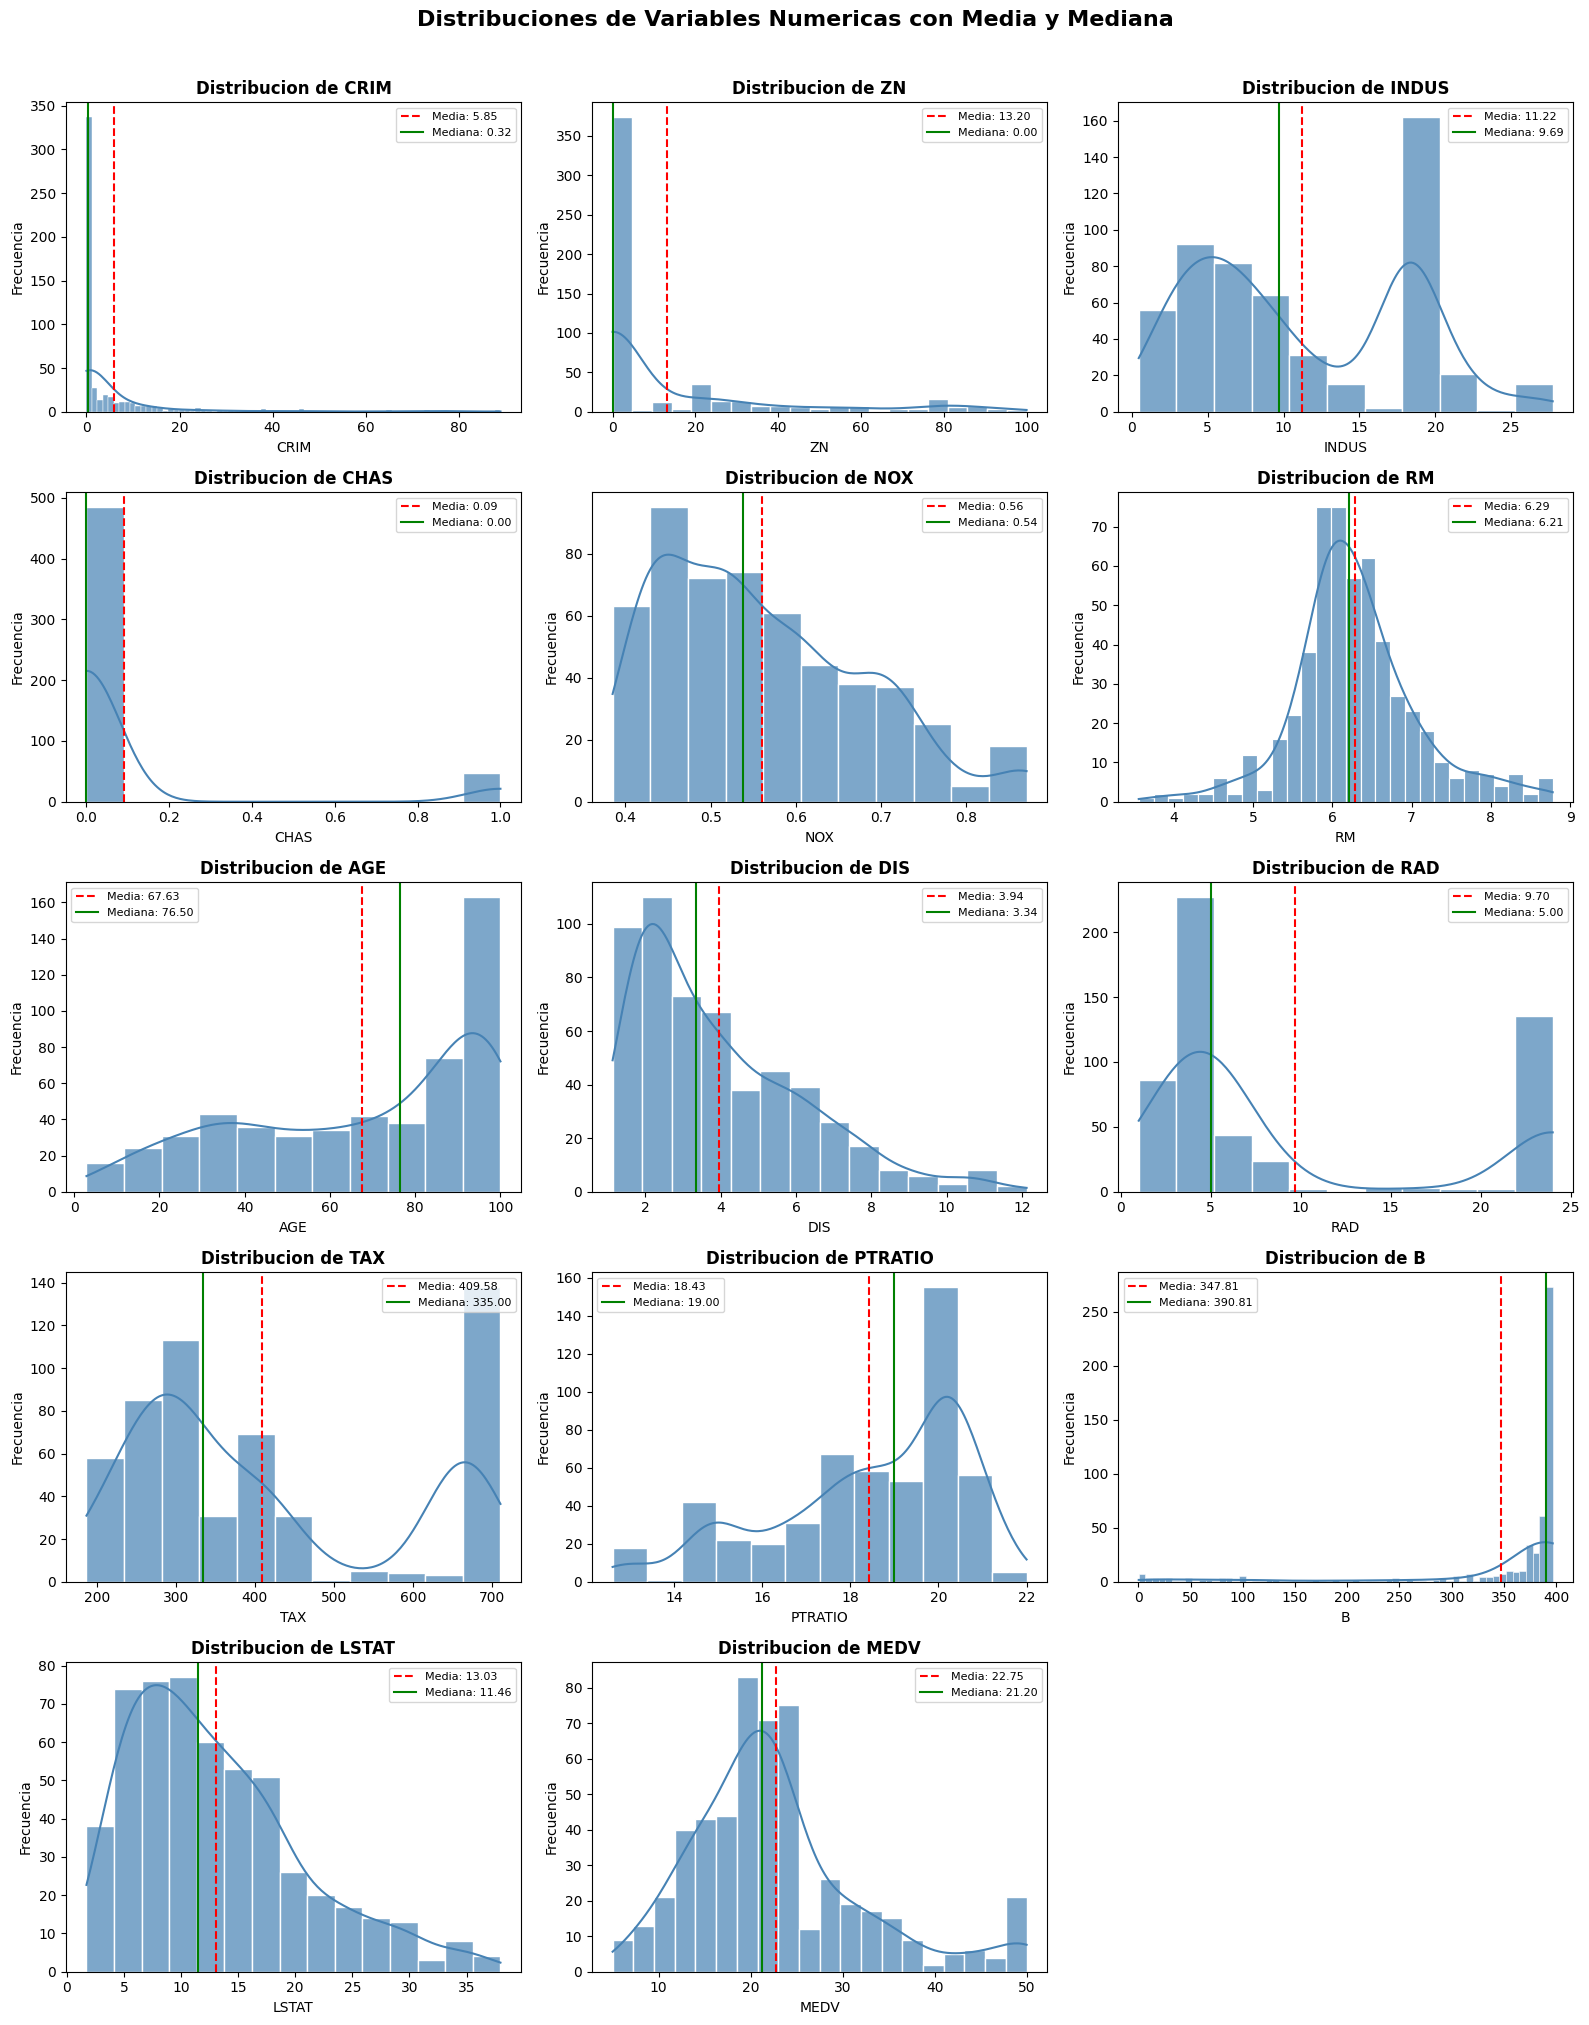

In [30]:
# Graficamos los histogramas y su estimación por densidad de kernel, junto con las métricas de media y mediana
# para cada una de las caracteristicas con el objetivo de visualizar y analizar su distribución
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

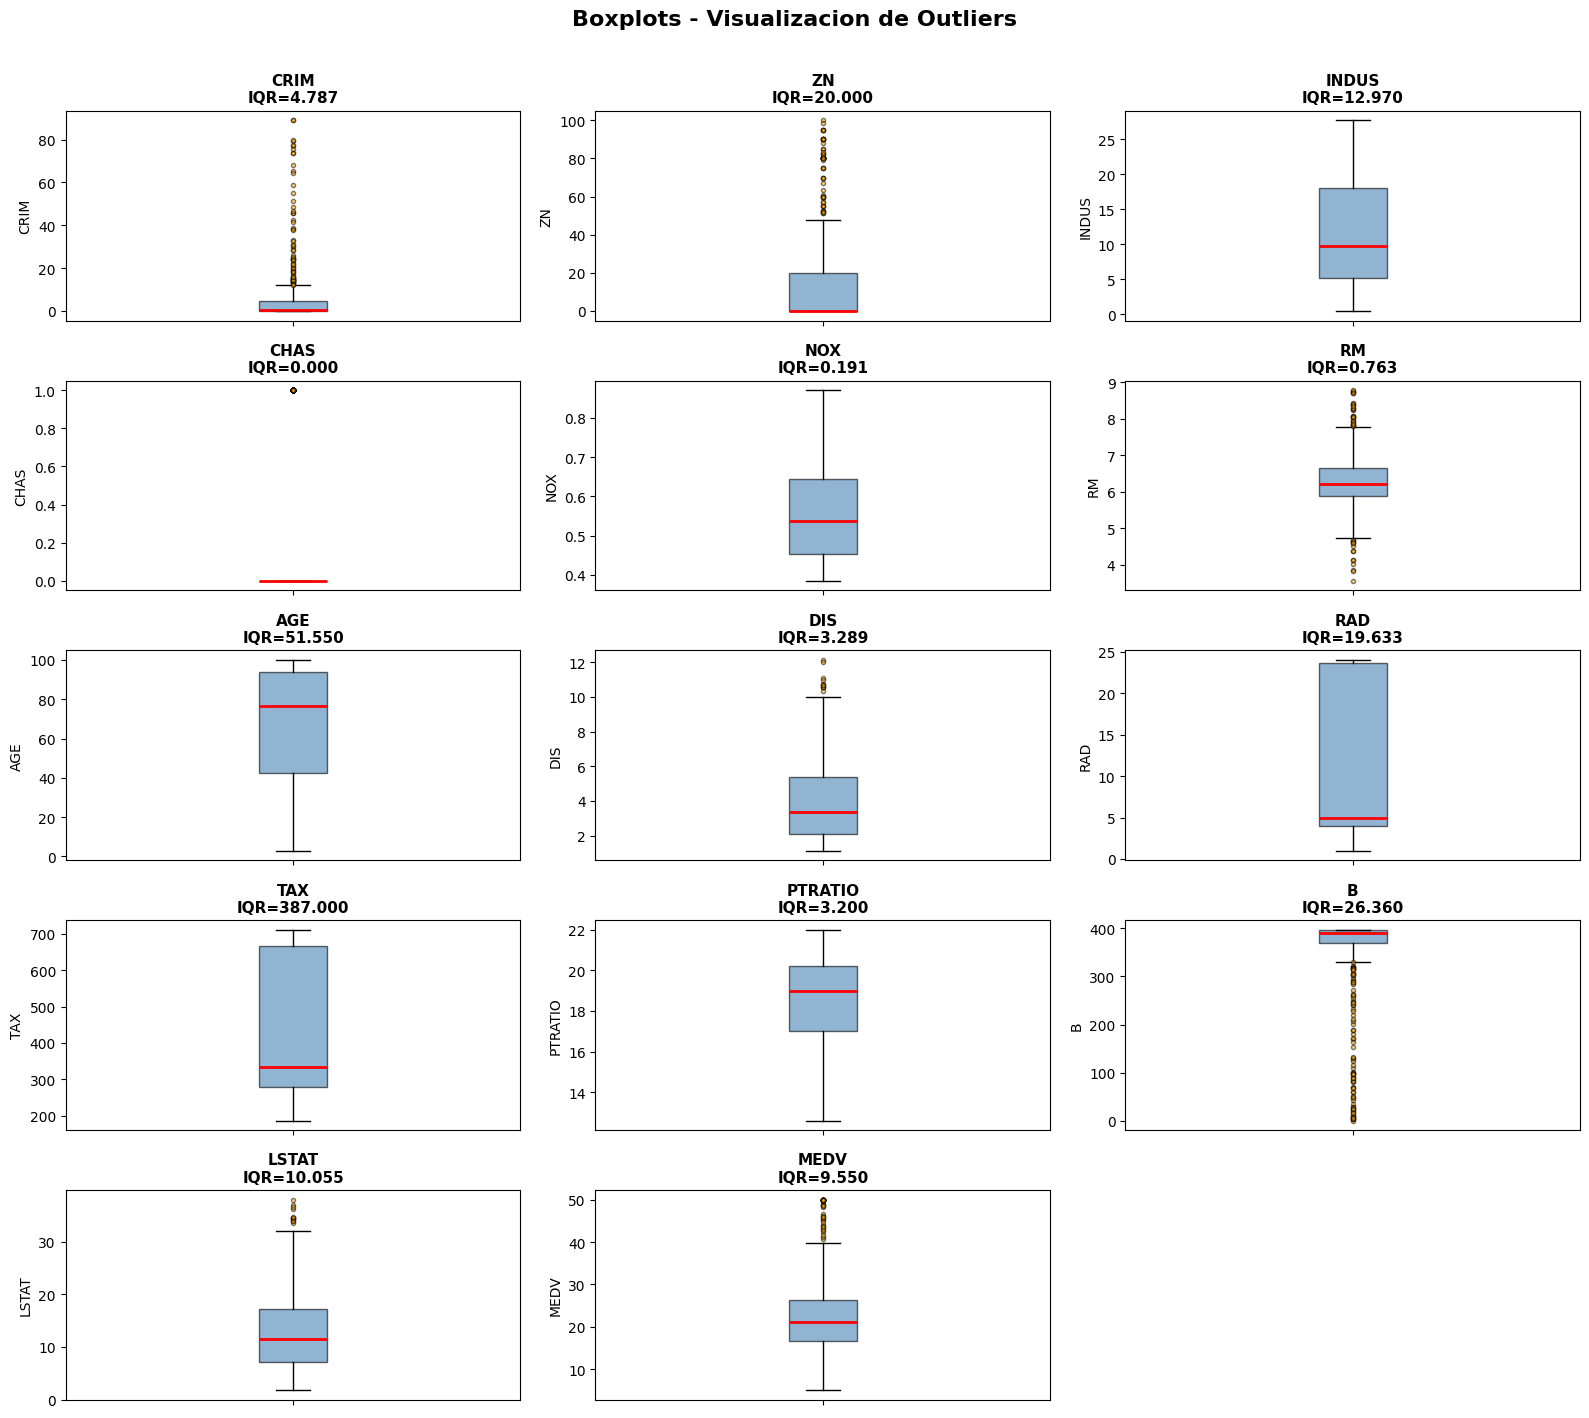

In [31]:
# Graficamos boxplots para cada una de las características así podemos visualizar
# la presencia de valores atípicos a partir de las métricas de cuartiles
fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [32]:
display(df["CHAS"].value_counts())
display(df["RAD"].value_counts())

,count
CHAS,
0.0,485
1.0,48


,count
RAD,
24.000000,132
5.000000,115
4.000000,110
3.000000,38
6.000000,26
2.000000,24
8.000000,24
1.000000,20
7.000000,17


In [34]:
# Pruebas para analizar la normalidad de las variables
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in cols_numericas:
    datos = df[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.469408,6.564120e-37,438.781447,5.245892e-96,No
1,ZN,0.597668,2.390123e-33,198.805731,6.759026e-44,No
2,INDUS,0.908474,1.601988e-17,374.197827,5.545928e-82,No
3,CHAS,0.321939,2.998017e-40,318.435853,7.120870e-70,No
4,NOX,0.937349,3.649405e-14,37.523405,7.110436e-09,No
5,RM,0.960145,7.475311e-11,32.676669,8.023270e-08,No
6,AGE,0.895926,1.576838e-18,155.421137,1.781267e-34,No
7,DIS,0.898663,1.901714e-18,81.238222,2.287411e-18,No
8,RAD,0.697593,1.071723e-29,143.112110,8.386873e-32,No
9,TAX,0.827971,1.304807e-23,314.934516,4.100517e-69,No


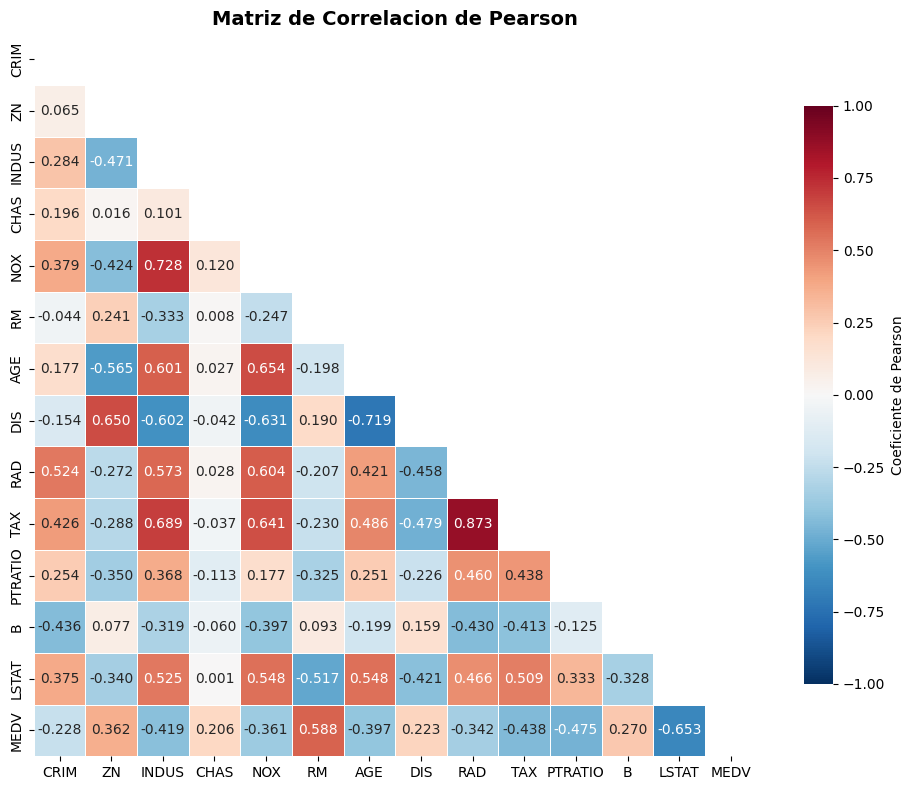

In [35]:
# Calculamos y graficamos a través de un heat map la matriz de correlación de Pearson
corr_pearson = df[df.columns].corr(method='pearson')

# Mascara triangular superior
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

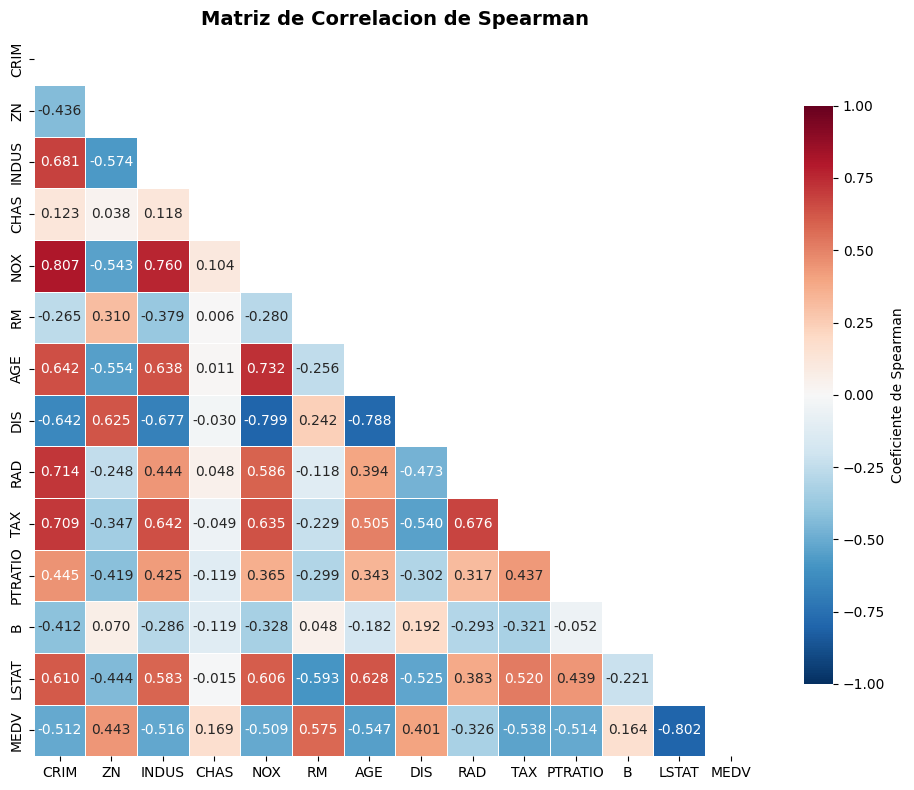

In [36]:
# Calculamos y graficamos a través de un heat map la matriz de correlación de Spearman
corr_spearman = df[df.columns].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman'})
ax.set_title('Matriz de Correlacion de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# Buscamos detectar colinealidad entre pares de variables del dataset
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |r_pearson| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_pearson.columns)):
    for j in range(i + 1, len(corr_pearson.columns)):
        r = corr_pearson.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_pearson.columns[i]
            var2 = corr_pearson.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).\n'
          f'Considerar eliminar variables redundantes o usar PCA.')

Pares con |r_pearson| >= 0.85 (posible colinealidad):
  RAD <-> TAX: r = 0.8731

Se detectaron 1 par(es) colineal(es).
Considerar eliminar variables redundantes o usar PCA.


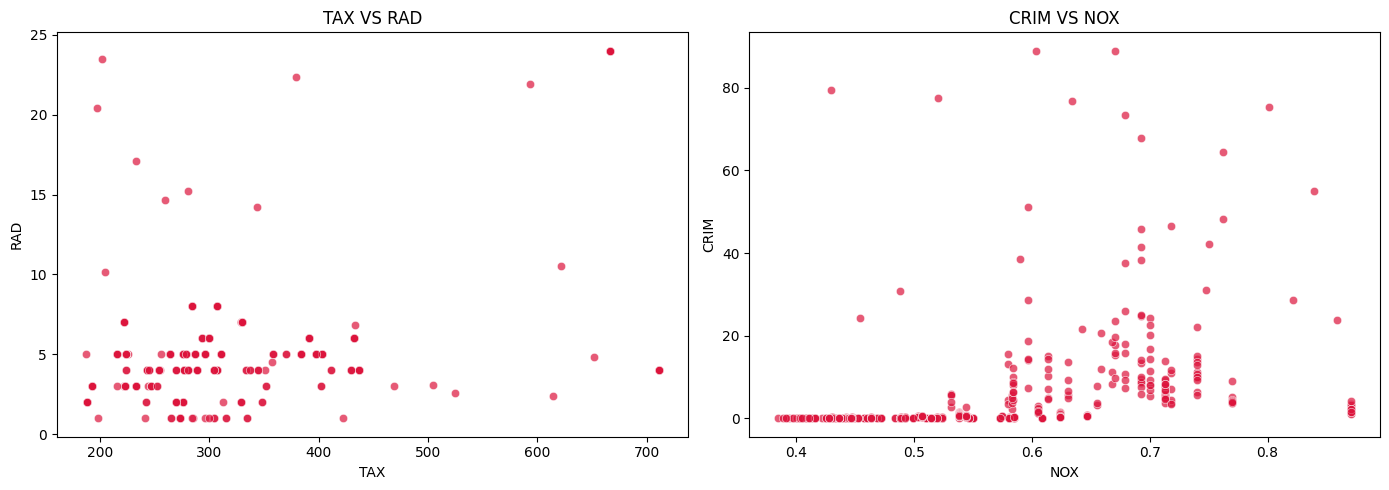

In [40]:
# Creamos la cuadrícula con 1 fila y 2 columnas para albergar exactamente los 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

sns.scatterplot(
    x=df["TAX"],
    y=df["RAD"],
    ax=axes[0],
    alpha=0.7,
    color="crimson"
)
axes[0].set_title("TAX VS RAD")
axes[0].set_xlabel("TAX")
axes[0].set_ylabel("RAD")

sns.scatterplot(
    x=df["NOX"],
    y=df["CRIM"],
    ax=axes[1],
    alpha=0.7,
    color="crimson"
)
axes[1].set_title("CRIM VS NOX")
axes[1].set_xlabel("NOX")
axes[1].set_ylabel("CRIM")

plt.tight_layout()
plt.show()

In [50]:
# Método a través de los cuartiles de las variables para verificar la cantidad
# de outliers que presenta cada una

for col in cols_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]

    print(f"{col}: {len(outliers)} outliers")

CRIM: 69 outliers
ZN: 60 outliers
INDUS: 0 outliers
CHAS: 48 outliers
NOX: 0 outliers
RM: 45 outliers
AGE: 0 outliers
DIS: 11 outliers
RAD: 0 outliers
TAX: 0 outliers
PTRATIO: 0 outliers
B: 91 outliers
LSTAT: 12 outliers
MEDV: 37 outliers


## 4. Análisis de datos faltantes

In [ ]:

#observamos que hay 506 registros totalmente integros, y los demas tienden a tener na, pensamos en quedarnos dropear registros la mitad o mas
#nulos debido a que sino estariamos creando sinteticamente el dataset
display(df.isna().sum(axis=1).value_counts().sort_index())


,count
0,506
1,5
2,3
3,11
4,3
5,3
6,2
7,5
8,4
9,4


## 5. Análisis de la variable RAD

In [ ]:
df["RAD"].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 , 19.26689099,  3.05654826, 23.51021334, 17.11018134,
       18.17750289,  2.40242419,  4.52856858,  2.57361455, 22.32831295,
       14.19552773, 20.41690761])

In [ ]:
print("Cantidad de valores unicos")
display(df["RAD"].nunique())
print("frecuencia de valores de RAD")
display(df["RAD"].value_counts())
#Salto la chafi


Cantidad de valores unicos


31

frecuencia de valores de RAD


,count
RAD,
24.000000,132
5.000000,115
4.000000,110
3.000000,38
6.000000,26
2.000000,24
8.000000,24
1.000000,20
7.000000,17


In [ ]:
#los valores reales son unicamente los numeros enteros, ya que logicamente,
# no existen autopistas con numeros con coma, parecen ser filas corruptas las que contienen los valores con coma,
#  ya que las filas que no tienen na tampoco tienen valores con coma
sucias = df.isna().any(axis=1)
print(sorted(df.loc[~sucias, 'RAD'].unique()))
print(sorted(df.loc[sucias, 'RAD'].dropna().unique()))

[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(24.0)]
[np.float64(1.3071276337271132), np.float64(2.402424185436736), np.float64(2.573614546445113), np.float64(3.056548264661834), np.float64(4.528568576401572), np.float64(4.811748400829242), np.float64(6.850122813308411), np.float64(10.1687011932127), np.float64(10.554891504036352), np.float64(14.195527728631848), np.float64(14.63832995512883), np.float64(15.239579433369125), np.float64(17.00015030082133), np.float64(17.110181340117375), np.float64(17.164569631646437), np.float64(18.177502888577678), np.float64(19.26689098525532), np.float64(20.41690761322129), np.float64(21.900776258906152), np.float64(22.069510849964647), np.float64(22.328312952252293), np.float64(23.510213342044743)]


## 6. Censura del target (MEDV)

In [ ]:
#observamos un truncamiento dentro del dataset a 50
display(df['MEDV'].value_counts())


,count
MEDV,
50.000000,16
25.000000,8
22.000000,7
21.700000,7
23.100000,7
...,...
12.800000,1
8.100000,1
13.651367,1




---
nuestro modelo va a tender a sub-estimar los valores de las casas ya que tienen un limite de 50000, pero es preferile eso a eliminar los datos por llamarlos sinteticos o corruptos y que no tengamos un rango mas acotado o menos conocimiento sobre como predecir precios altos


## 7. Limpieza del dataset

## Eliminamos los RAD corruptos y los que no contienen target
ya que no podés usarlas ni para entrenar porque necesitás el target para calcular el error ni para test porque necesitás el target real para comparar contra la predicción


In [ ]:
#MEDV faltante -> no hay target, no sirve para entrenar ni evaluar
medv_faltante = df["MEDV"].isna()
#las filas con la mitad o mas features que sean nulas tambien tomamos la decision de eliminarlas para no generar datos tan artificiales
#filas con 7 o mas NA
demasiados_na = df[df.columns].isna().sum(axis=1) > 6

# Filas a eliminar
a_eliminar = medv_faltante | demasiados_na


df_limpio = df.loc[~a_eliminar].copy()


RAD_VALIDOS = [1, 2, 3, 4, 5, 6, 7, 8, 24]

# 1) redondeamos la parte decimal: 6.85 -> 7 (los NaN quedan como NaN)
df_limpio["RAD"] = np.round(df_limpio["RAD"])

# 2) Eliminamos las filas cuyo RAD, ya redondeado, no pertenece al dominio válido.
#    Los NaN se conservan: se imputan después del split.
rad_fuera_de_dominio = df_limpio["RAD"].notna() & ~df_limpio["RAD"].isin(RAD_VALIDOS)
df_limpio = df_limpio.loc[~rad_fuera_de_dominio]

print(f"Filas originales: {len(df)}")
print(f"Filas originales: {len(df) - len(df_limpio)}")
print(f"Filas restantes: {len(df_limpio)}")



Filas originales: 556
Filas originales: 36
Filas restantes: 520


In [ ]:
#estas son la frecuencia de datos con features faltantes
display(df_limpio.isna().sum(axis=1).value_counts().sort_index())



,count
0,506
1,2
2,1
3,7
4,2
5,1
6,1


In [ ]:
print("Cantidad de valores unicos")
display(df_limpio["RAD"].nunique())
print("frecuencia de valores de RAD")
display(df_limpio["RAD"].value_counts())


Cantidad de valores unicos


9

frecuencia de valores de RAD


,count
RAD,
24.0,132
5.0,116
4.0,110
3.0,40
6.0,26
2.0,25
8.0,24
1.0,20
7.0,18


##